# Phase 2: The Baseline Classifier (Naive Bayes)

## 🏗 Overview: The "Fast & Logical" First Model
In this phase, we build our initial classifier using **Multinomial Naive Bayes**.

###  Why Naive Bayes?
1.  **Transparency (The White Box)**: This model is based on pure probability (counting word frequencies). We can see exactly which words define Fake vs Real news, making it perfect for our final presentation.
2.  **Benchmark Strategy**: Before trying complex "Black Box" Neural Networks, we must set a benchmark. If a simple model performs exceptionally well, we save the company (or instructors) time and resources.
3.  **Speed**: It is lightning-fast, allowing us to iterate quickly even on large datasets like this (~40,000 articles).

In [8]:
import os
import pandas as pd
import numpy as np
import joblib
import nltk
import re
import string
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Colab Integration: Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/Project 2/project-nlp-challenge'
    print("✅ Running in Colab. Google Drive mounted.")
except ImportError:
    BASE_PATH = '.'
    print("💻 Running Locally.")

# NLTK Downloads for ephemeral environments
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Ensure directories exist
os.makedirs(os.path.join(BASE_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'dataset'), exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Running in Colab. Google Drive mounted.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Data Ingestion (The Sliced Ingredients)
We load our stratified Train and Test sets created in Phase 1.

In [9]:
train_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/train.csv'))
test_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/test.csv'))

# Load the fitted vectorizer
tfidf = joblib.load(os.path.join(BASE_PATH, 'models/vectorizer.joblib'))

print(f"Data Loaded. Train: {train_df.shape}, Test: {test_df.shape}")

Data Loaded. Train: (31953, 7), Test: (7989, 7)


## 2. Transformation
We convert the cleaned text into their TF-IDF numerical vectors.

In [10]:
X_train = tfidf.transform(train_df['cleaned_text'].astype(str))
y_train = train_df['label']

X_test = tfidf.transform(test_df['cleaned_text'].astype(str))
y_test = test_df['label']

print("Vectors Generated.")

Vectors Generated.


## 3. Training: The Multinomial Naive Bayes
We train the model on our training data.

In [12]:
# 1. Instantiate and Train Naive Bayes (Standard)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
joblib.dump(nb_model, os.path.join(BASE_PATH, 'models/nb_tfidf_classifier.joblib'))

# 2. Train Logistic Regression (For Comparison Phase)
lr_tfidf_model = LogisticRegression(max_iter=1000)
lr_tfidf_model.fit(X_train, y_train)
joblib.dump(lr_tfidf_model, os.path.join(BASE_PATH, 'models/lr_tfidf_classifier.joblib'))
print("Both Models (NB & LR) Trained and Persistent.")


Both Models (NB & LR) Trained and Persistent.


### 🏆 Persistence & Comparison Training
We save our model and train a secondary Logistic Regression to compare in the next phase.


## 4. Evaluation & Visualization
How well does our model perform on the 'Final Exam' (The test set)?


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      3989
           1       0.94      0.94      0.94      4000

    accuracy                           0.94      7989
   macro avg       0.94      0.94      0.94      7989
weighted avg       0.94      0.94      0.94      7989



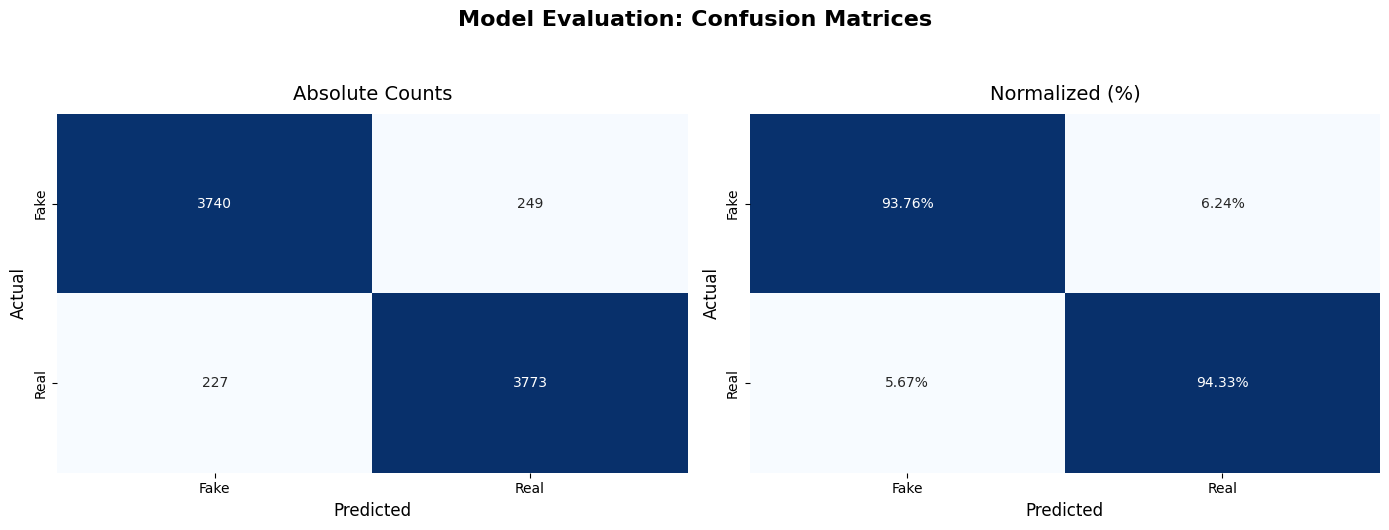



🎯 Keywords to REAL NEWS:
['washington reuters' 'reuters us' 'reuters' 'myanmar' 'catalan'
 'rohingya' 'reuters president' 'catalonia' 'moscow reuters'
 'told reuters']

🚩 Keywords to FAKE NEWS:
['image via' 'screen capture' '2017realdonaldtrump' 'getty' 'screenshot'
 'getty images' 'gop' 'featured image' 'video screen' 'hilarious']


In [23]:
y_pred = nb_model.predict(X_test)
print()
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))


# 1. Confusion Matrix

# 1.1 Calculate both matrices (Counts and Percentages)
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# 1.2 Create the figure with 1 row and 2 columns side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Absolute Confusion Matrix (Left) ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            cbar=False) # Remove colorbar for a cleaner look
ax[0].set_title('Absolute Counts', fontsize=14, pad=10)
ax[0].set_xlabel('Predicted', fontsize=12)
ax[0].set_ylabel('Actual', fontsize=12)

# --- PLOT 2: Normalized Confusion Matrix (Right) ---
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax[1],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            cbar=False)
ax[1].set_title('Normalized (%)', fontsize=14, pad=10)
ax[1].set_xlabel('Predicted', fontsize=12)
ax[1].set_ylabel('Actual', fontsize=12)

# Add a main title for the entire figure
plt.suptitle('Model Evaluation: Confusion Matrices', fontsize=16, fontweight='bold', y=1.05)
# Adjust the spacing between subplots automatically to prevent overlap
plt.tight_layout()
plt.show()

print()

# 2. Identify the words that best define each class (Naive Bayes)

feature_names = tfidf.get_feature_names_out()
# Log-probabilidades de las palabras para cada clase
probs = nb_model.feature_log_prob_
# Creamos un dataframe con las palabras y sus pesos
words_df = pd.DataFrame({
    'word': feature_names,
    'fake_weight': probs[0],
    'real_weight': probs[1]
})

words_df['diff'] = words_df['real_weight'] - words_df['fake_weight']
print("\n🎯 Keywords to REAL NEWS:")
print(words_df.sort_values(by='diff', ascending=False).head(10)['word'].values)
print("\n🚩 Keywords to FAKE NEWS:")
print(words_df.sort_values(by='diff', ascending=True).head(10)['word'].values)

We see that the word ‘reuters’ is a very strong predictor of real news. This tells us that the model performs very well on this dataset, but if we feed it a real news article that is NOT from Reuters, it might struggle a bit more. This is a bias in the dataset that we've identified thanks to the transparency of the Naive Bayes model.

## 5. Final Deliverable: Validation Predictions
we must predict labels for `validation_data.csv` and ensure the output file has **NO extra columns** and maintains the exact original format.

In [24]:
val_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/validation_data.csv'))

# 1. Applying exactly the same fusion and cleaning logic
# Note: In a production setting, we would import the clean_text function from a module.
def clean_text(text):
    import re, string
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    if pd.isna(text): return ""
    text = text.lower()
    pattern = re.compile('[%s]' % re.escape(string.punctuation))
    text = pattern.sub('', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(filtered_tokens)

print("Scrubbing validation data...")
val_full_text = (val_df['title'] + " " + val_df['text']).apply(clean_text)

# 2. Vectorization
X_val = tfidf.transform(val_full_text)

# 3. Prediction
val_df['label'] = nb_model.predict(X_val)

# 4. Final Guard: Export strictly following original format
# Columns required: original columns only, no 'full_text' or 'cleaned_text' helper columns
final_output_path = os.path.join(BASE_PATH, 'dataset/validation_results.csv')
val_df.to_csv(final_output_path, index=False)

print(f"✅ Validation predictions saved to: {final_output_path}")
print("Format Verified: Exactly like validation_data.csv.")

Scrubbing validation data...
✅ Validation predictions saved to: /content/drive/MyDrive/Project 2/project-nlp-challenge/dataset/validation_results.csv
Format Verified: Exactly like validation_data.csv.
